# 07 - Caracterização da base e positividade

Caracteriza a **tabela canônica** (`analysis_dataset.parquet`) e
checa a condição de **positividade** exigida pela identificação causal (todo contexto
precisa ter chance de receber cada estratégia).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

NB_DIR        = Path().resolve()
PROJECT_DIR   = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

df  = pd.read_parquet(PROCESSED_DIR / "analysis_dataset.parquet")
exp = pd.read_parquet(PROCESSED_DIR / "experiments.parquet")

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

STRAT_ORDER = ["oversampling", "cost_sensitive", "undersampling", "other"]
print(f"Tabela canônica: {df.shape[0]} pares × {df.shape[1]} colunas")

Tabela canônica: 425 pares × 23 colunas


## 1. Resumo geral

Do corpus bruto à base analítica: quanto sobra após exigir baseline + tratamento +
métrica compartilhada no grupo.

In [2]:
print("Corpus extraído (experiments.parquet):")
print(f"  Experimentos:            {len(exp):,}")
print(f"  Papers:                  {exp['paper_id'].nunique():,}")
print(f"  Grupos within-paper:     {exp['within_paper_group_id'].nunique():,}")
print()
print("Base analítica (analysis_dataset.parquet):")
print(f"  Pares (grupo, estrat.):  {len(df):,}")
print(f"  Grupos utilizáveis:      {df['within_paper_group_id'].nunique():,}")
print(f"  Papers cobertos:         {df['paper_id'].nunique():,}")
print(f"  Datasets distintos:      {df['dataset_canonical'].nunique():,}")
print(f"  Experimentos cobertos:   {df['within_paper_group_id'].nunique() + len(df):,} (1 baseline + tratamentos por grupo)")

Corpus extraído (experiments.parquet):
  Experimentos:            1,309
  Papers:                  199
  Grupos within-paper:     676

Base analítica (analysis_dataset.parquet):
  Pares (grupo, estrat.):  425
  Grupos utilizáveis:      279
  Papers cobertos:         129
  Datasets distintos:      169
  Experimentos cobertos:   704 (1 baseline + tratamentos por grupo)


## 2. Distribuição das estratégias

strategy
oversampling      156
cost_sensitive     79
undersampling      32
other             158


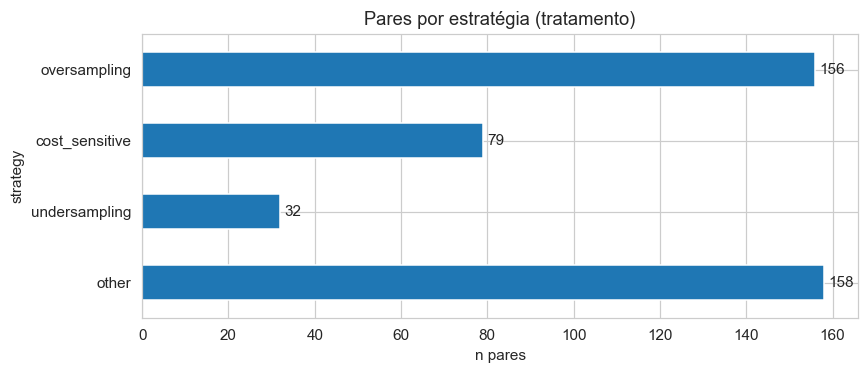

In [3]:
vc = df["strategy"].value_counts().reindex(STRAT_ORDER)
print(vc.to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
vc.iloc[::-1].plot(kind="barh", color="C0", ax=ax)
ax.set_title("Pares por estratégia (tratamento)")
ax.set_xlabel("n pares")
for i, v in enumerate(vc.iloc[::-1]):
    ax.text(v + 1, i, str(int(v)), va="center")
plt.tight_layout()
plt.show()

## 3. Distribuição das covariáveis Z

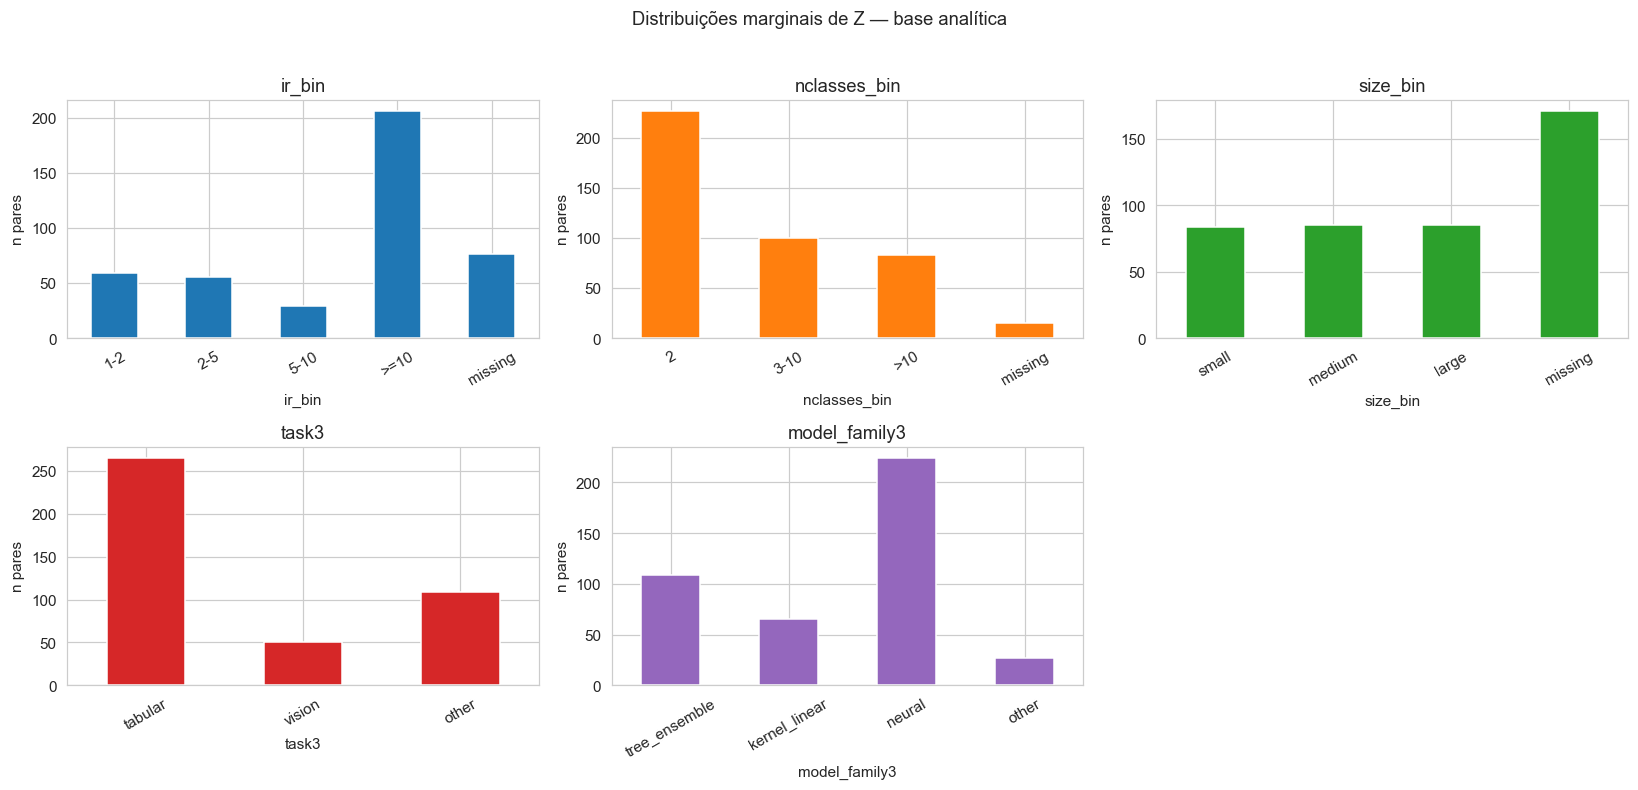

In [4]:
Z_ORDERS = {
    "ir_bin":        ["1-2", "2-5", "5-10", ">=10", "missing"],
    "nclasses_bin":  ["2", "3-10", ">10", "missing"],
    "size_bin":      ["small", "medium", "large", "missing"],
    "task3":         ["tabular", "vision", "other"],
    "model_family3": ["tree_ensemble", "kernel_linear", "neural", "other"],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()
for i, (col, order) in enumerate(Z_ORDERS.items()):
    vc = df[col].value_counts().reindex(order).fillna(0)
    vc.plot(kind="bar", ax=axes[i], color=f"C{i}")
    axes[i].set_title(col)
    axes[i].set_ylabel("n pares")
    axes[i].tick_params(axis="x", rotation=30)
axes[-1].axis("off")
plt.suptitle("Distribuições marginais de Z — base analítica", y=1.02)
plt.tight_layout()
plt.show()

## 4. Imbalance ratio (nível de grupo)

IR varia várias ordens de grandeza; resumo no nível de grupo (não de par) para não
ponderar grupos com mais tratamentos.

IR por grupo (com IR reportado):
  n grupos:  219
  mediana:   10.0
  Q1 / Q3:   2.5 / 99.8
  máx:       5000
  grupos sem IR: 60


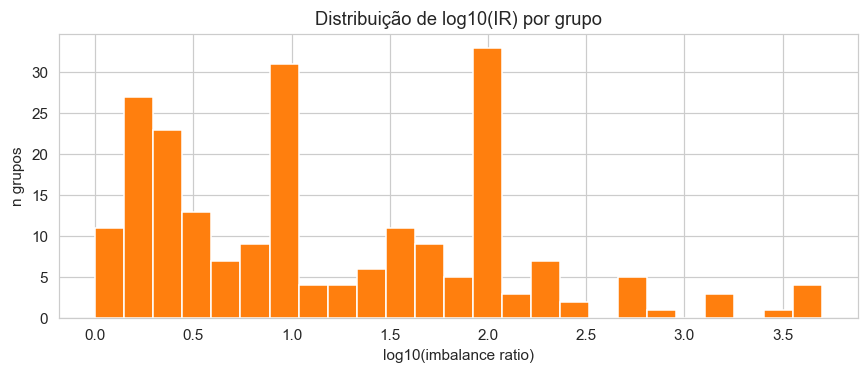

In [5]:
grp_ir = df.groupby("within_paper_group_id")["ir"].first().dropna()
print("IR por grupo (com IR reportado):")
print(f"  n grupos:  {grp_ir.size}")
print(f"  mediana:   {grp_ir.median():.1f}")
print(f"  Q1 / Q3:   {grp_ir.quantile(0.25):.1f} / {grp_ir.quantile(0.75):.1f}")
print(f"  máx:       {grp_ir.max():.0f}")
print(f"  grupos sem IR: {(df.groupby('within_paper_group_id')['ir_missing'].first()).sum()}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(np.log10(grp_ir), bins=25, color="C1", edgecolor="white")
ax.set_title("Distribuição de log10(IR) por grupo")
ax.set_xlabel("log10(imbalance ratio)")
ax.set_ylabel("n grupos")
plt.tight_layout()
plt.show()

## 5. Cobertura de métricas (μ_g por grupo)

Qual métrica "venceu" a prioridade em cada grupo. ΔY é relativo, então μ_g pode
diferir entre grupos — mas registramos a distribuição.

metric_used
metric_accuracy        99
metric_f1_binary       83
metric_aucroc          36
metric_gmean           16
metric_f1_macro        16
metric_balanced_acc    14
metric_auprc            7
metric_mcc              5
metric_f1_micro         3


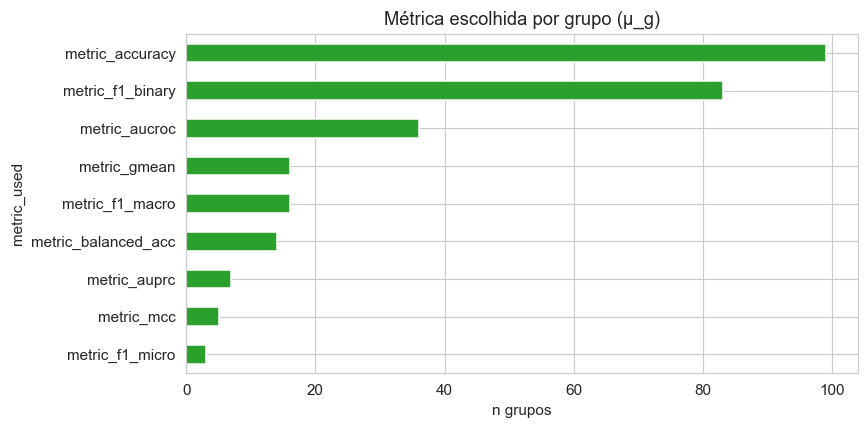

In [6]:
mu = df.groupby("within_paper_group_id")["metric_used"].first().value_counts()
print(mu.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
mu.iloc[::-1].plot(kind="barh", color="C2", ax=ax)
ax.set_title("Métrica escolhida por grupo (μ_g)")
ax.set_xlabel("n grupos")
plt.tight_layout()
plt.show()

## 6. Positividade

A identificação exige que cada contexto possa receber cada estratégia.


Estratégia × ir_bin:
ir_bin          1-2  2-5  5-10  >=10  missing
strategy                                     
oversampling     34   36    18    38       30
cost_sensitive    3    1     3    62       10
undersampling     7    5     1    12        7
other            15   13     7    94       29

Estratégia × model_family3:
model_family3   tree_ensemble  kernel_linear  neural  other
strategy                                                   
oversampling               61             38      39     18
cost_sensitive              1              0      76      2
undersampling              12              7      12      1
other                      35             20      97      6

Estratégia × task3:
task3           tabular  vision  other
strategy                              
oversampling        140       6     10
cost_sensitive       13      20     46
undersampling        28       2      2
other                84      23     51


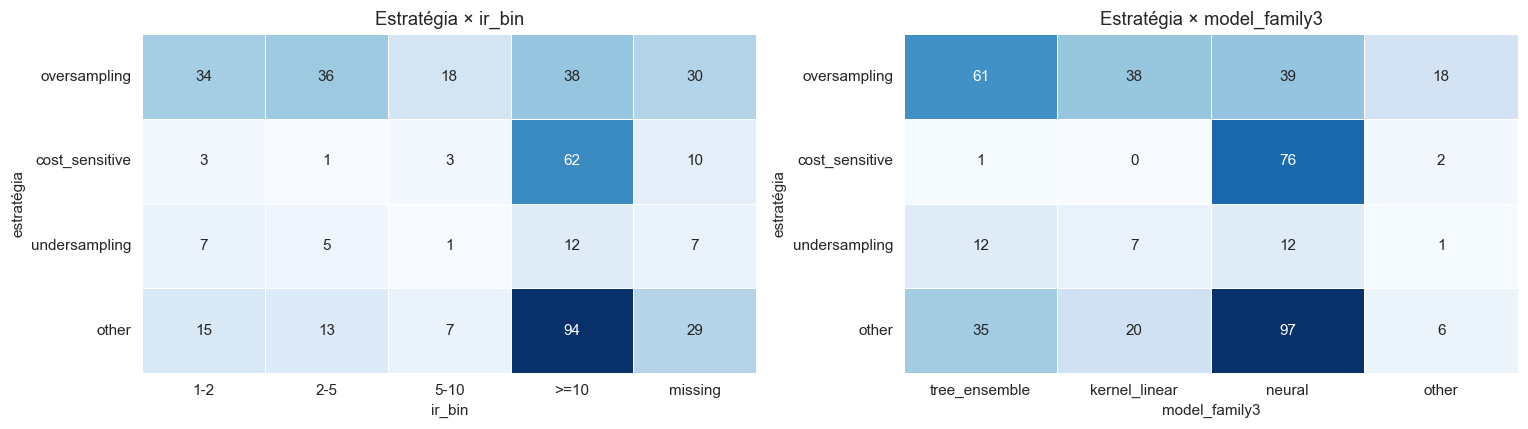


Células com suporte fraco (0 < n < 5):
  ir_bin         cost_sensitive 1-2        n=3
  ir_bin         cost_sensitive 2-5        n=1
  ir_bin         cost_sensitive 5-10       n=3
  ir_bin         undersampling  5-10       n=1
  model_family3  cost_sensitive tree_ensemble n=1
  model_family3  cost_sensitive other      n=2
  model_family3  undersampling  other      n=1
  task3          undersampling  vision     n=2
  task3          undersampling  other      n=2
→ CATEs nessas células devem ser lidos com cautela (IC largos).


In [7]:
def positivity(dim, order):
    ct = pd.crosstab(df["strategy"], df[dim]).reindex(index=STRAT_ORDER)
    ct = ct.reindex(columns=[c for c in order if c in ct.columns], fill_value=0)
    return ct

for dim, order in [("ir_bin", Z_ORDERS["ir_bin"]),
                   ("model_family3", Z_ORDERS["model_family3"]),
                   ("task3", Z_ORDERS["task3"])]:
    print(f"\nEstratégia × {dim}:")
    print(positivity(dim, order).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, dim in zip(axes, ["ir_bin", "model_family3"]):
    sns.heatmap(positivity(dim, Z_ORDERS[dim]), annot=True, fmt="d",
                cmap="Blues", cbar=False, linewidths=0.4, ax=ax)
    ax.set_title(f"Estratégia × {dim}")
    ax.set_xlabel(dim); ax.set_ylabel("estratégia")
plt.tight_layout()
plt.show()

MIN_CELL = 5
weak = []
for dim in ["ir_bin", "model_family3", "task3"]:
    ct = positivity(dim, Z_ORDERS[dim])
    for s in ct.index:
        for c in ct.columns:
            if 0 < ct.loc[s, c] < MIN_CELL:
                weak.append((dim, s, c, int(ct.loc[s, c])))
print(f"\nCélulas com suporte fraco (0 < n < {MIN_CELL}):")
for dim, s, c, n in weak:
    print(f"  {dim:14} {s:14} {c:10} n={n}")
print("→ CATEs nessas células devem ser lidos com cautela (IC largos).")

## 7. ΔY por estratégia

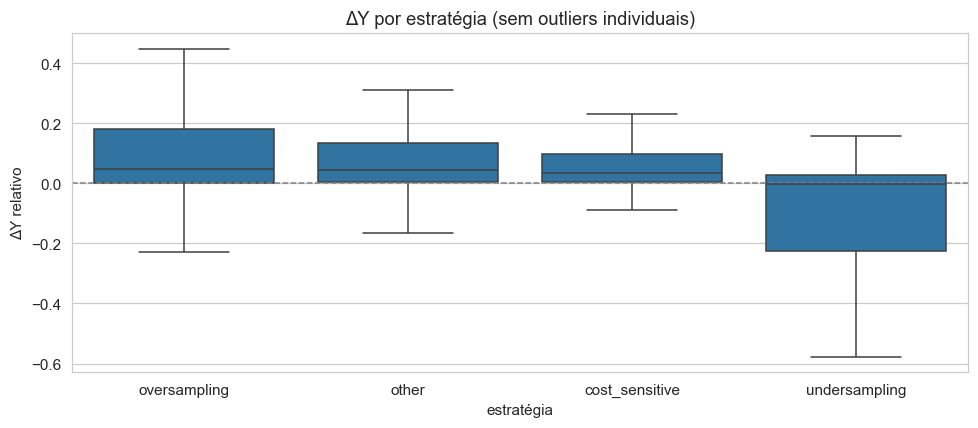

                count  median   mean
strategy                            
oversampling      156   0.046  0.679
cost_sensitive     79   0.033  0.105
undersampling      32  -0.003  0.372
other             158   0.043  0.741


In [8]:
order = (df.groupby("strategy")["delta_y"].median()
         .reindex(STRAT_ORDER).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x="strategy", y="delta_y", order=order,
            showfliers=False, color="C0", ax=ax)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_title("ΔY por estratégia (sem outliers individuais)")
ax.set_ylabel("ΔY relativo"); ax.set_xlabel("estratégia")
plt.tight_layout()
plt.show()

print(df.groupby("strategy")["delta_y"]
      .agg(["count", "median", "mean"]).reindex(STRAT_ORDER).round(3).to_string())